# Actividad 4 · Optimización controlada de un ensamble
## 1. Problema, datos y protocolo
Se utiliza **Breast Cancer Wisconsin (Diagnostic)**, distribuido por UCI y disponible en Scikit-learn. Cada observación representa una muestra de una masa mamaria obtenida por aspiración con aguja fina; las 30 variables describen características de los núcleos celulares en imágenes digitalizadas. Hay 569 observaciones. Fuente original: https://doi.org/10.24432/C5DW2B. Carga reproducible: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html.

El objetivo es clasificar muestras malignas y benignas. Recodificamos **maligno=1, benigno=0** (Scikit-learn entrega el orden inverso). La métrica principal será **F1 de la clase maligna**, que combina precisión y sensibilidad y evita depender de accuracy ante clases desiguales. Se reportan también recall, precision, accuracy y ROC-AUC. F1 no incorpora costos clínicos específicos: este es un ejercicio académico.

Se fija semilla 42, división estratificada 80/20 y cinco folds estratificados. Se comparan Random Forest base, el mismo bosque con 15 variables y el bosque reducido con hiperparámetros optimizados. La reducción a 15 se fija antes de mirar resultados. Todas las decisiones se toman con entrenamiento; las evaluaciones de prueba se presentan juntas al final, incluso para la tabla base/reducido. No se modifica el procedimiento tras observar prueba.

**Colab:** subir este `.ipynb` y seleccionar Entorno de ejecución → Ejecutar todas. Solo requiere CPU. Los CSV y gráficas se guardan en `resultados/`. Las salidas adjuntas se generan mediante ejecución de Python; no se afirma una ejecución remota en Colab si no se ha verificado.

In [1]:
import sys, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
SEED=42
OUT=Path('resultados'); OUT.mkdir(exist_ok=True)
versions={'python':platform.python_version(), 'sklearn':sklearn.__version__, 'numpy':np.__version__, 'pandas':pd.__version__}
print(versions)
(OUT/'versiones.json').write_text(json.dumps(versions, indent=2))


{'python': '3.13.15', 'sklearn': '1.6.1', 'numpy': '2.1.3', 'pandas': '2.2.3'}


88

## 2. Preparación y auditoría
Todas las características son numéricas. Se revisan faltantes, tipos, duplicados y clases. El identificador de fila solo sirve para rastrear la partición y nunca entra al modelo. El CSV original conserva la codificación de Scikit-learn; el procesado incluye las variables sin escalar, la nueva etiqueta y la partición. El escalado y la imputación se aprenden dentro de cada pipeline, no en el CSV completo.

In [8]:
data=load_breast_cancer(as_frame=True)
original=data.frame.copy()
original.to_csv(OUT/'dataset_original_sklearn.csv', index=False)
X=data.data.copy()
y=(data.target==0).astype(int).rename('maligno')
print('Dimensiones:', X.shape)
display(pd.DataFrame({'tipo':X.dtypes.astype(str), 'faltantes':X.isna().sum(), 'min':X.min(), 'max':X.max()}))
print('Duplicados completos:', original.duplicated().sum())
print('Predictores duplicados:', X.duplicated().sum())
assert not X.duplicated().any(), 'Revisar duplicados antes de dividir.'
display(y.value_counts().rename_axis('maligno').to_frame('cantidad'))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,stratify=y,random_state=SEED)
display(pd.DataFrame({'entrenamiento':y_train.value_counts(), 'prueba':y_test.value_counts()}))
processed=X.copy(); processed['maligno']=y
processed['particion']=np.where(X.index.isin(X_train.index),'entrenamiento','prueba')
processed.to_csv(OUT/'dataset_procesado.csv',index_label='id_fila')
assert set(X_train.index).isdisjoint(X_test.index)


Dimensiones: (569, 30)


,tipo,faltantes,min,max
mean radius,float64,0,6.981000,28.11000
mean texture,float64,0,9.710000,39.28000
mean perimeter,float64,0,43.790000,188.50000
mean area,float64,0,143.500000,2501.00000
mean smoothness,float64,0,0.052630,0.16340
mean compactness,float64,0,0.019380,0.34540
mean concavity,float64,0,0.000000,0.42680
mean concave points,float64,0,0.000000,0.20120
mean symmetry,float64,0,0.106000,0.30400
mean fractal dimension,float64,0,0.049960,0.09744


Duplicados completos: 0
Predictores duplicados: 0


,cantidad
maligno,
0,357
1,212


,entrenamiento,prueba
maligno,,
0,285,72
1,170,42


## 3. Modelo base y análisis de redundancia
El modelo base utiliza 100 árboles, profundidad sin límite, `min_samples_split=2`, `max_features="sqrt"`, semilla 42 y un solo hilo para comparar tiempos. El pipeline imputa por mediana y estandariza de manera consistente. Los árboles prácticamente no requieren escalado porque dividen por umbrales; se incluye para documentar el tratamiento de escalas, sin asumir que mejora al bosque.

La correlación se inspecciona solo en entrenamiento. **SelectKBest con ANOVA F** conserva las 15 variables con mayor separación entre clases en relación con su variabilidad interna. Es una selección univariada: mantiene nombres e interpretación, pero puede retener predictores correlacionados y perder interacciones útiles. No garantiza eliminar toda redundancia.

In [3]:
corr=X_train.corr().abs()
pairs=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)).stack().sort_values(ascending=False)
display(pairs.head(12).rename('correlacion_absoluta').to_frame())
def pipeline(reduced=False):
    return Pipeline([('imputar',SimpleImputer(strategy='median')),
                     ('escalar',StandardScaler()),
                     ('seleccionar',SelectKBest(f_classif,k=15) if reduced else 'passthrough'),
                     ('rf',RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=1))])
base=pipeline(); reduced=pipeline(True)
cv=list(StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED).split(X_train,y_train))
scores={}
for name,model in [('Base',base),('Reducido',reduced)]:
    scores[name]=cross_validate(model,X_train,y_train,cv=cv,scoring='f1',return_train_score=True,n_jobs=1)
display(pd.DataFrame({name:{'F1 CV media':s['test_score'].mean(),'F1 CV DE':s['test_score'].std(ddof=1),'F1 entrenamiento':s['train_score'].mean()} for name,s in scores.items()}).T)


correlacion_absoluta
mean radius     mean perimeter               0.997815
worst radius    worst perimeter              0.993719
mean radius     mean area                    0.986740
mean perimeter  mean area                    0.985960
worst radius    worst area                   0.983107
worst perimeter worst area                   0.976665
radius error    perimeter error              0.974705
mean perimeter  worst perimeter              0.970006
                worst radius                 0.969332
mean radius     worst radius                 0.969256
                worst perimeter              0.964439
mean area       worst radius                 0.960725

,F1 CV media,F1 CV DE,F1 entrenamiento
Base,0.951945,0.023179,1.0
Reducido,0.931096,0.031596,1.0


## 4. Búsqueda sistemática
Se aplica GridSearchCV al pipeline reducido completo: 2×2×2×2=16 combinaciones y 5 folds (80 ajustes más el reajuste final). Se exploran número de árboles, profundidad, tamaño mínimo de división y variables candidatas por nodo. El criterio es F1 de malignidad. La selección de variables, la imputación y el escalado se reaprenden en cada fold.

Los mismos folds permiten comparar alternativas en varias subdivisiones en lugar de depender de una única separación. La desviación estándar describe variación entre folds, no un intervalo de confianza. Buscar muchas configuraciones también puede sobreajustar la validación; por eso la prueba se reserva y no decide hiperparámetros.

In [4]:
grid={'rf__n_estimators':[100,200], 'rf__max_depth':[None,6],
      'rf__min_samples_split':[2,6], 'rf__max_features':['sqrt',.7]}
search=GridSearchCV(pipeline(True),grid,scoring='f1',cv=cv,n_jobs=1,return_train_score=True,refit=True)
t0=time.perf_counter(); search.fit(X_train,y_train); search_seconds=time.perf_counter()-t0
display(pd.DataFrame([{'Hiperparametro':p,'Valores explorados':str(vals),'Mejor valor':str(search.best_params_[p])} for p,vals in grid.items()]))
results=pd.DataFrame(search.cv_results_)
display(results[['params','mean_test_score','std_test_score','mean_train_score','mean_fit_time','rank_test_score']].sort_values('rank_test_score').head(8))
results.to_csv(OUT/'busqueda_cv.csv',index=False)
print('Tiempo total de búsqueda (incluye refit):',round(search_seconds,3),'segundos')
print('Mejor F1 CV:',search.best_score_)
# Recomendación fijada con CV, antes de abrir prueba: regla de una DE/raíz(5).
cv_mean={'Base':scores['Base']['test_score'].mean(),'Reducido':scores['Reducido']['test_score'].mean(),'Optimizado':search.best_score_}
cv_sd={'Base':scores['Base']['test_score'].std(ddof=1),'Reducido':scores['Reducido']['test_score'].std(ddof=1),'Optimizado':results.loc[search.best_index_,'std_test_score']*np.sqrt(5/4)}
best_cv=max(cv_mean,key=cv_mean.get)
threshold=cv_mean[best_cv]-cv_sd[best_cv]/np.sqrt(5)
eligible=[name for name in ['Reducido','Base','Optimizado'] if cv_mean[name]>=threshold]
recommended=eligible[0]
print('Recomendación por CV y parsimonia:',recommended)


,Hiperparametro,Valores explorados,Mejor valor
0,rf__n_estimators,"[100, 200]",200
1,rf__max_depth,"[None, 6]",None
2,rf__min_samples_split,"[2, 6]",6
3,rf__max_features,"['sqrt', 0.7]",sqrt


,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time,rank_test_score
3,"{'rf__max_depth': None, 'rf__max_features': 's...",0.931760,0.025579,0.992598,0.587718,1
11,"{'rf__max_depth': 6, 'rf__max_features': 'sqrt...",0.931760,0.025579,0.988842,0.485588,1
2,"{'rf__max_depth': None, 'rf__max_features': 's...",0.931550,0.026519,0.991138,0.680398,3
1,"{'rf__max_depth': None, 'rf__max_features': 's...",0.931306,0.027384,1.000000,1.042226,4
0,"{'rf__max_depth': None, 'rf__max_features': 's...",0.931096,0.028260,1.000000,0.536384,5
10,"{'rf__max_depth': 6, 'rf__max_features': 'sqrt...",0.928403,0.029181,0.984414,0.311257,6
8,"{'rf__max_depth': 6, 'rf__max_features': 'sqrt...",0.927949,0.030726,0.994080,0.214185,7
9,"{'rf__max_depth': 6, 'rf__max_features': 'sqrt...",0.927949,0.030726,0.995561,0.427149,7


Tiempo total de búsqueda (incluye refit): 48.451 segundos
Mejor F1 CV: 0.9317600558009765
Recomendación por CV y parsimonia: Base


La regla anterior prefiere el reducido de configuración inicial si queda dentro de un error estándar del mejor F1 CV; después el base y finalmente el optimizado. Es una heurística de parsimonia, no una prueba estadística, y favorece evitar el costo de ajuste cuando la diferencia es pequeña. El F1 CV del ganador de la búsqueda tiene sesgo de selección: requeriría validación anidada para estimar con mayor rigor todo el procedimiento.

## 5. Evaluación final bajo las mismas condiciones
Se entrenan los tres pipelines en el mismo conjunto de entrenamiento y se evalúan una sola vez en prueba. El tiempo de ajuste incluye preprocesamiento y selección, pero no la búsqueda, cuyo costo se registra por separado. Los tiempos dependen del hardware y son mediciones aproximadas de una ejecución.

In [5]:
models={'Base':clone(base),'Reducido':clone(reduced),'Optimizado':clone(search.best_estimator_)}
rows=[]; predictions={}
for name,model in models.items():
    t0=time.perf_counter(); model.fit(X_train,y_train); elapsed=time.perf_counter()-t0
    pred=model.predict(X_test); proba=model.predict_proba(X_test)[:,1]; predictions[name]=pred
    rows.append({'Modelo':name,'F1 maligno':f1_score(y_test,pred),'Recall maligno':recall_score(y_test,pred),
                 'Precision maligno':precision_score(y_test,pred),'Accuracy':accuracy_score(y_test,pred),
                 'ROC-AUC':roc_auc_score(y_test,proba),'Caracteristicas':model.named_steps['rf'].n_features_in_,
                 'Ajuste segundos':elapsed,'F1 CV':cv_mean[name],'DE CV':cv_sd[name],
                 'F1 train':f1_score(y_train,model.predict(X_train))})
comparison=pd.DataFrame(rows).set_index('Modelo')
display(Markdown('### Comparación base frente a selección'))
display(comparison.loc[['Base','Reducido']].round(4))
display(Markdown('### Comparación final de las tres configuraciones'))
display(comparison.round(4))
comparison.to_csv(OUT/'comparacion.csv')
selected=X.columns[models['Reducido'].named_steps['seleccionar'].get_support()].tolist()
print('Variables conservadas (15):',selected)
display(pd.DataFrame({'Variable':X.columns,'F ANOVA':models['Reducido'].named_steps['seleccionar'].scores_,
                      'Conservada':models['Reducido'].named_steps['seleccionar'].get_support()}).sort_values('F ANOVA',ascending=False))
(OUT/'variables_seleccionadas.json').write_text(json.dumps(selected,indent=2))
pd.DataFrame({'id_fila':X_test.index,'real':y_test.to_numpy(),**predictions}).to_csv(OUT/'predicciones_prueba.csv',index=False)


### Comparación base frente a selección

,F1 maligno,Recall maligno,Precision maligno,Accuracy,ROC-AUC,Caracteristicas,Ajuste segundos,F1 CV,DE CV,F1 train
Modelo,,,,,,,,,,
Base,0.9630,0.9286,1.0,0.9737,0.9929,30,0.2860,0.9519,0.0232,1.0
Reducido,0.9367,0.8810,1.0,0.9561,0.9921,15,0.2386,0.9311,0.0316,1.0


### Comparación final de las tres configuraciones

,F1 maligno,Recall maligno,Precision maligno,Accuracy,ROC-AUC,Caracteristicas,Ajuste segundos,F1 CV,DE CV,F1 train
Modelo,,,,,,,,,,
Base,0.9630,0.9286,1.0,0.9737,0.9929,30,0.2860,0.9519,0.0232,1.0000
Reducido,0.9367,0.8810,1.0,0.9561,0.9921,15,0.2386,0.9311,0.0316,1.0000
Optimizado,0.9367,0.8810,1.0,0.9561,0.9917,15,0.4694,0.9318,0.0286,0.9941


Variables conservadas (15): ['mean radius', 'mean perimeter', 'mean area', 'mean compactness', 'mean concavity', 'mean concave points', 'radius error', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area', 'worst compactness', 'worst concavity', 'worst concave points']


,Variable,F ANOVA,Conservada
27,worst concave points,733.724933,True
22,worst perimeter,717.246487,True
20,worst radius,692.861395,True
7,mean concave points,684.526845,True
2,mean perimeter,548.413236,True
23,worst area,522.188947,True
0,mean radius,511.274848,True
3,mean area,444.857518,True
6,mean concavity,397.592082,True
26,worst concavity,319.507776,True


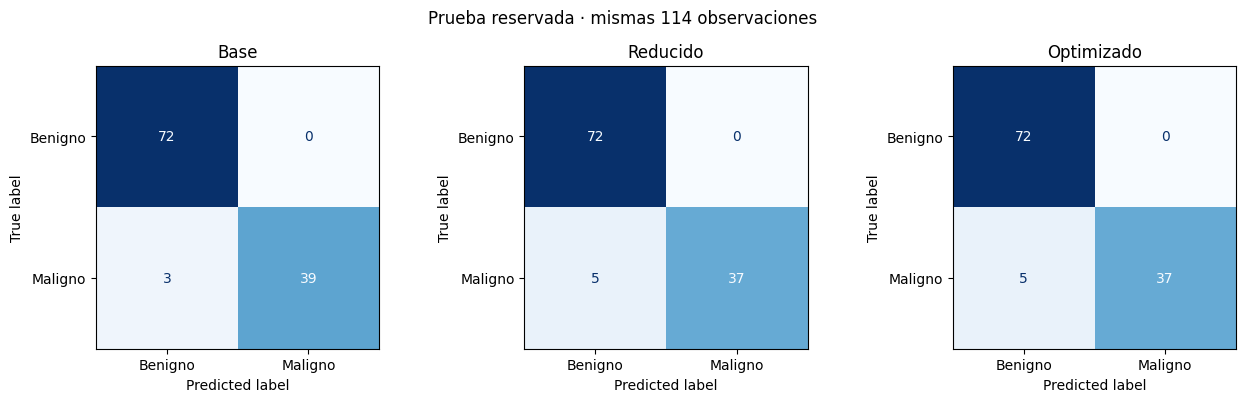

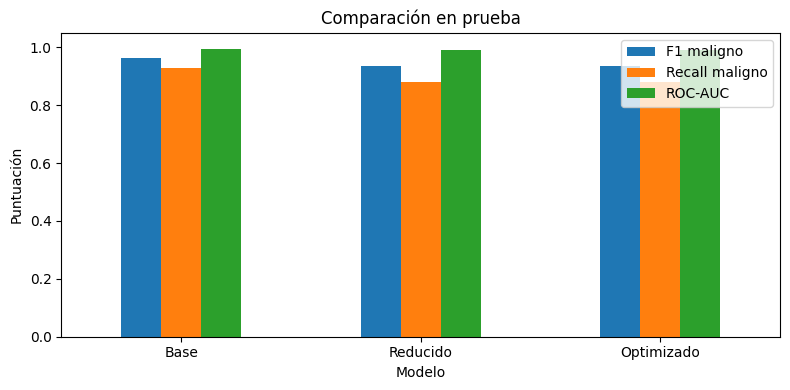

In [6]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,(name,model) in zip(axes,models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test,predictions[name],display_labels=['Benigno','Maligno'],ax=ax,colorbar=False,cmap='Blues')
    ax.set_title(name)
fig.suptitle('Prueba reservada · mismas 114 observaciones'); fig.tight_layout()
fig.savefig(OUT/'matrices_confusion.png',dpi=160,bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(figsize=(8,4))
comparison[['F1 maligno','Recall maligno','ROC-AUC']].plot.bar(ax=ax,rot=0,ylim=(0,1.05))
ax.set_title('Comparación en prueba'); ax.set_ylabel('Puntuación'); fig.tight_layout()
fig.savefig(OUT/'comparacion_metricas.png',dpi=160,bbox_inches='tight'); plt.show()


## 6. Incertidumbre y análisis
Para no equiparar una diferencia pequeña con evidencia concluyente, calculamos un intervalo percentil bootstrap **pareado y estratificado** para la diferencia de F1 (optimizado − base). Se remuestrean las mismas filas para ambos modelos, conservando los tamaños de clase. Los modelos no se reentrenan: el intervalo refleja variación de esta prueba condicionada a los modelos, no la incertidumbre completa del entrenamiento. No se usa para retocar la búsqueda.

In [7]:
rng=np.random.default_rng(SEED)
yt=y_test.to_numpy(); idx0=np.flatnonzero(yt==0); idx1=np.flatnonzero(yt==1)
deltas=[]
for _ in range(2000):
    ids=np.r_[rng.choice(idx0,len(idx0),replace=True),rng.choice(idx1,len(idx1),replace=True)]
    deltas.append(f1_score(yt[ids],predictions['Optimizado'][ids],zero_division=0)-f1_score(yt[ids],predictions['Base'][ids],zero_division=0))
lo,hi=np.quantile(deltas,[.025,.975])
print(f'IC bootstrap 95% de diferencia F1: [{lo:.4f}, {hi:.4f}]')
b,r,o=[comparison.loc[k] for k in ['Base','Reducido','Optimizado']]
reduction_delta=r['F1 maligno']-b['F1 maligno']
tuning_delta=o['F1 maligno']-r['F1 maligno']
total_delta=o['F1 maligno']-b['F1 maligno']
effect='selección de variables' if abs(reduction_delta)>=abs(tuning_delta) else 'ajuste de hiperparámetros'
verdict='superó numéricamente' if total_delta>0 else ('igualó' if total_delta==0 else 'no superó')
evidence='El intervalo incluye cero; no hay evidencia clara de una ventaja en esta prueba.' if lo<=0<=hi else 'El intervalo no incluye cero, aunque solo describe esta muestra y los modelos ya ajustados.'
display(Markdown(f'''### Conclusión
La **{effect}** produjo el mayor cambio absoluto entre etapas. La selección cambió el F1 en **{reduction_delta:+.4f}** y la búsqueda añadió **{tuning_delta:+.4f}**. El optimizado **{verdict}** al base: F1 **{o['F1 maligno']:.4f}** frente a **{b['F1 maligno']:.4f}**, diferencia **{total_delta:+.4f}**. {evidence}

La representación reducida conserva **15 de 30 variables (50%)** con interpretación directa. La reducción {'mejoró el F1 observado' if reduction_delta>0 else 'conservó el F1 observado' if reduction_delta==0 else 'perdió F1 observado'}, por lo que reducir dimensiones no garantiza mejorar la clasificación. Los tiempos de ajuste fueron **{b['Ajuste segundos']:.3f} s**, **{r['Ajuste segundos']:.3f} s** y **{o['Ajuste segundos']:.3f} s**; la búsqueda exigió además **{search_seconds:.2f} s**. Debe distinguirse este costo inicial del costo de entrenar la configuración ya elegida.

La configuración recomendada por el criterio fijado con entrenamiento es **{recommended}**. No cambiamos esa decisión mirando prueba. Los valores de CV y sus desviaciones en la tabla permiten valorar si una ganancia pequeña compensa el costo de búsqueda. Un bosque sigue siendo menos interpretable que un árbol único; retener nombres facilita explicar entradas, pero las asociaciones ANOVA no son causales y las variables correlacionadas dificultan atribuir importancia. El escalado no es esencial para estos árboles. Las diferencias entre F1 de entrenamiento y validación ayudan a detectar optimismo; la búsqueda de la mejor media puede sobreajustar los folds.

**Limitación:** una única división, un dataset pequeño y un bootstrap sin reentrenamiento no permiten establecer una mejora generalizable a otra población. **Acción posterior:** validación cruzada anidada repetida y evaluación en un conjunto externo, con costos de falsos negativos definidos antes del ajuste. No se concluye que optimizar garantice una ventaja real.'''))


IC bootstrap 95% de diferencia F1: [-0.0682, 0.0000]


### Conclusión
La **selección de variables** produjo el mayor cambio absoluto entre etapas. La selección cambió el F1 en **-0.0263** y la búsqueda añadió **+0.0000**. El optimizado **no superó** al base: F1 **0.9367** frente a **0.9630**, diferencia **-0.0263**. El intervalo incluye cero; no hay evidencia clara de una ventaja en esta prueba.

La representación reducida conserva **15 de 30 variables (50%)** con interpretación directa. La reducción perdió F1 observado, por lo que reducir dimensiones no garantiza mejorar la clasificación. Los tiempos de ajuste fueron **0.286 s**, **0.239 s** y **0.469 s**; la búsqueda exigió además **48.45 s**. Debe distinguirse este costo inicial del costo de entrenar la configuración ya elegida.

La configuración recomendada por el criterio fijado con entrenamiento es **Base**. No cambiamos esa decisión mirando prueba. Los valores de CV y sus desviaciones en la tabla permiten valorar si una ganancia pequeña compensa el costo de búsqueda. Un bosque sigue siendo menos interpretable que un árbol único; retener nombres facilita explicar entradas, pero las asociaciones ANOVA no son causales y las variables correlacionadas dificultan atribuir importancia. El escalado no es esencial para estos árboles. Las diferencias entre F1 de entrenamiento y validación ayudan a detectar optimismo; la búsqueda de la mejor media puede sobreajustar los folds.

**Limitación:** una única división, un dataset pequeño y un bootstrap sin reentrenamiento no permiten establecer una mejora generalizable a otra población. **Acción posterior:** validación cruzada anidada repetida y evaluación en un conjunto externo, con costos de falsos negativos definidos antes del ajuste. No se concluye que optimizar garantice una ventaja real.

## Fuentes y entregables
- UCI, Breast Cancer Wisconsin (Diagnostic): https://doi.org/10.24432/C5DW2B
- Cargador y descripción: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Selección de características: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html
- GridSearchCV: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

La carpeta `resultados/` contiene el dataset original distribuido por Scikit-learn, CSV procesado con partición, comparaciones, búsqueda, predicciones, nombres seleccionados, versiones y dos gráficas. El CSV procesado no debe reutilizarse ajustando transformaciones sobre todas sus filas: se debe respetar la columna de partición.